In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv")
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [3]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [4]:
df.tail()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2
17965,Focus,2015,8299,Manual,5007,Petrol,22,57.7,1.0


In [5]:
df.isna().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [6]:
df.shape

(17966, 9)

In [7]:
df.sample()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
13877,Focus,2017,10690,Manual,37351,Diesel,0,74.3,1.5


In [8]:
df.dtypes

model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

In [9]:
df['model'].value_counts()

model
 Fiesta                   6557
 Focus                    4588
 Kuga                     2225
 EcoSport                 1143
 C-MAX                     543
 Ka+                       531
 Mondeo                    526
 B-MAX                     355
 S-MAX                     296
 Grand C-MAX               247
 Galaxy                    228
 Edge                      208
 KA                        199
 Puma                       80
 Tourneo Custom             69
 Grand Tourneo Connect      59
 Mustang                    57
 Tourneo Connect            33
 Fusion                     16
 Streetka                    2
 Ranger                      1
 Escort                      1
 Transit Tourneo             1
Focus                        1
Name: count, dtype: int64

In [10]:
df['transmission'].value_counts()

transmission
Manual       15518
Automatic     1361
Semi-Auto     1087
Name: count, dtype: int64

In [11]:
df['fuelType'].value_counts()

fuelType
Petrol      12179
Diesel       5762
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64

<Axes: xlabel='year', ylabel='Count'>

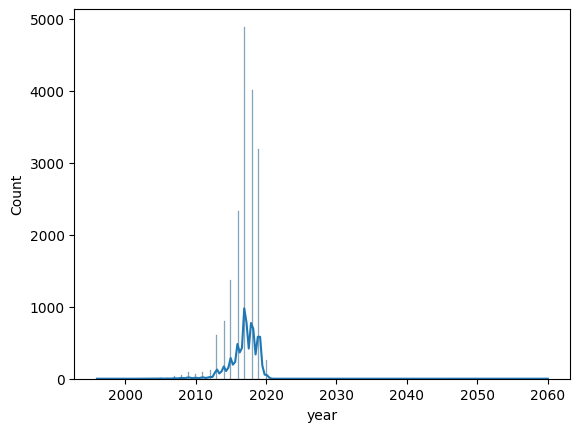

In [12]:
sns.histplot(df['year'],kde = True)

<Axes: ylabel='price'>

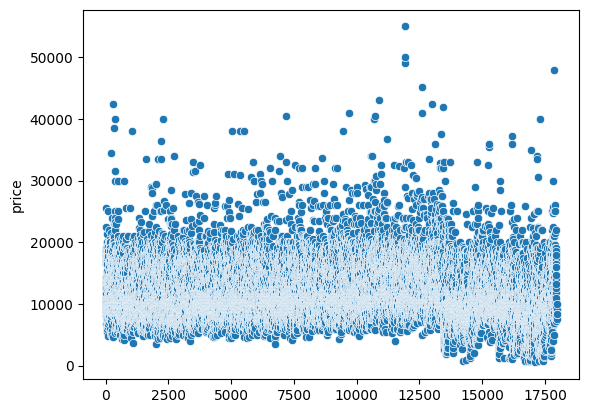

In [13]:
sns.scatterplot(df['price'])

<Axes: xlabel='price', ylabel='Count'>

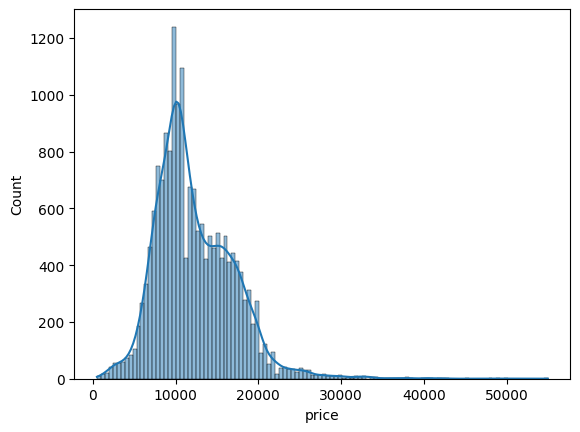

In [14]:
sns.histplot(df['price'],kde = True)

<Axes: xlabel='mileage', ylabel='Count'>

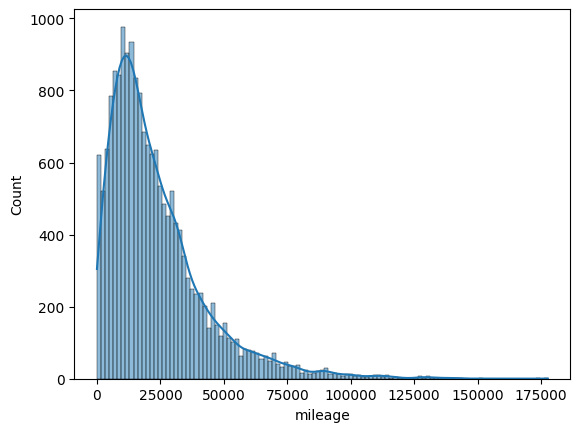

In [15]:
sns.histplot(df['mileage'],kde = True)

<Axes: xlabel='count', ylabel='model'>

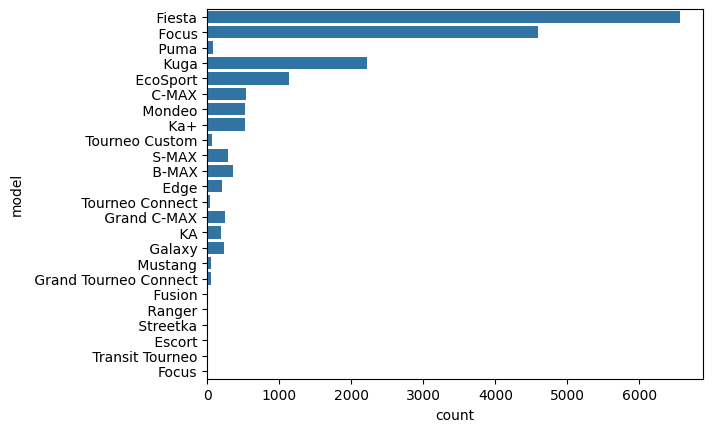

In [16]:
sns.countplot(df['model'])

<Axes: xlabel='transmission', ylabel='count'>

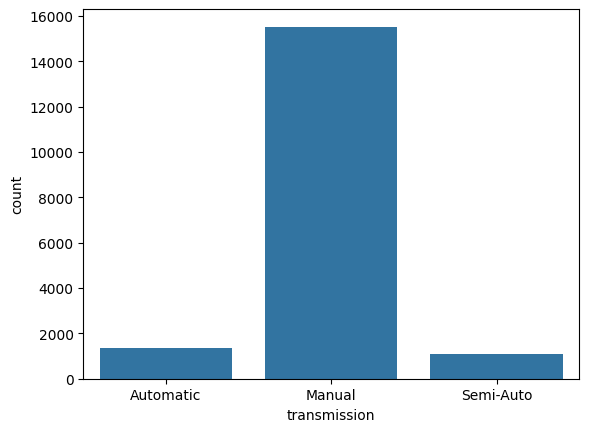

In [17]:
sns.countplot(x = df['transmission'])

<Axes: xlabel='fuelType', ylabel='count'>

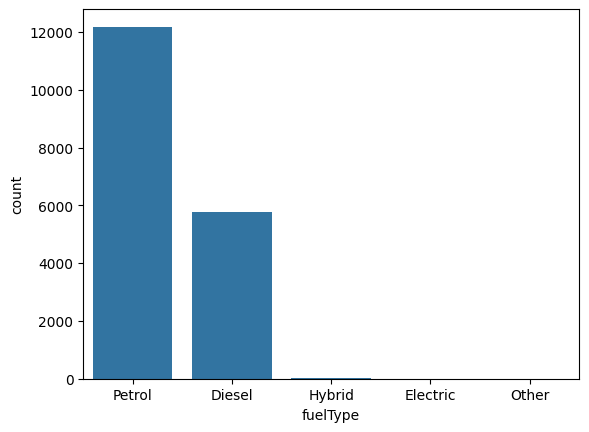

In [18]:
sns.countplot(x = df['fuelType'])

In [19]:
df['engineSize'].value_counts()

engineSize
1.0    7765
1.5    3418
2.0    3311
1.2    1626
1.6     923
1.1     559
1.4     112
2.3      80
0.0      51
5.0      45
1.8      35
2.2      13
2.5      13
1.3      13
3.2       1
1.7       1
Name: count, dtype: int64

<Axes: xlabel='engineSize', ylabel='count'>

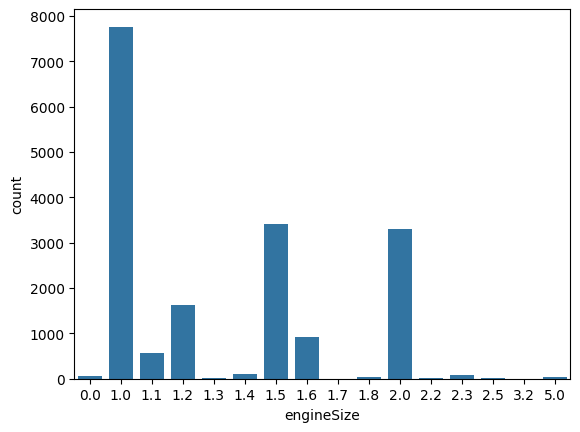

In [20]:
sns.countplot(x = df['engineSize'])

In [21]:
df.sample()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
5814,Focus,2017,11991,Semi-Auto,8805,Petrol,145,51.4,1.0


In [22]:
df = pd.get_dummies(df,columns = ['model'])
df.head(1)

,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,...,model_ Mondeo,model_ Mustang,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus
0,2017,12000,Automatic,15944,Petrol,150,57.7,1.0,False,False,...,False,False,False,False,False,False,False,False,False,False


In [23]:
df = pd.get_dummies(df,columns = ['fuelType'])
df.head(1)

,year,price,transmission,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,...,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,Automatic,15944,150,57.7,1.0,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [24]:
df = pd.get_dummies(df,columns = ['transmission'])
df.head(1)

,year,price,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,...,model_ Transit Tourneo,model_Focus,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,transmission_Automatic,transmission_Manual,transmission_Semi-Auto
0,2017,12000,15944,150,57.7,1.0,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False


In [25]:
df = pd.get_dummies(df,columns = ['engineSize'])
df.head()

,year,price,mileage,tax,mpg,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,engineSize_1.5,engineSize_1.6,engineSize_1.7,engineSize_1.8,engineSize_2.0,engineSize_2.2,engineSize_2.3,engineSize_2.5,engineSize_3.2,engineSize_5.0
0,2017,12000,15944,150,57.7,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2018,14000,9083,150,57.7,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2017,13000,12456,150,57.7,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2019,17500,10460,145,40.3,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,2019,16500,1482,145,48.7,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [26]:
df.columns

Index(['year', 'price', 'mileage', 'tax', 'mpg', 'model_ B-MAX',
       'model_ C-MAX', 'model_ EcoSport', 'model_ Edge', 'model_ Escort',
       'model_ Fiesta', 'model_ Focus', 'model_ Fusion', 'model_ Galaxy',
       'model_ Grand C-MAX', 'model_ Grand Tourneo Connect', 'model_ KA',
       'model_ Ka+', 'model_ Kuga', 'model_ Mondeo', 'model_ Mustang',
       'model_ Puma', 'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'fuelType_Diesel',
       'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other',
       'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual',
       'transmission_Semi-Auto', 'engineSize_0.0', 'engineSize_1.0',
       'engineSize_1.1', 'engineSize_1.2', 'engineSize_1.3', 'engineSize_1.4',
       'engineSize_1.5', 'engineSize_1.6', 'engineSize_1.7', 'engineSize_1.8',
       'engineSize_2.0', 'engineSize_2.2', 'engineSize_2.3', 'engineSize_2.5

In [27]:
cols = [ 'model_ B-MAX',
       'model_ C-MAX', 'model_ EcoSport', 'model_ Edge', 'model_ Escort',
       'model_ Fiesta', 'model_ Focus', 'model_ Fusion', 'model_ Galaxy',
       'model_ Grand C-MAX', 'model_ Grand Tourneo Connect', 'model_ KA',
       'model_ Ka+', 'model_ Kuga', 'model_ Mondeo', 'model_ Mustang',
       'model_ Puma', 'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'fuelType_Diesel',
       'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other',
       'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual',
       'transmission_Semi-Auto', 'engineSize_0.0', 'engineSize_1.0',
       'engineSize_1.1', 'engineSize_1.2', 'engineSize_1.3', 'engineSize_1.4',
       'engineSize_1.5', 'engineSize_1.6', 'engineSize_1.7', 'engineSize_1.8',
       'engineSize_2.0', 'engineSize_2.2', 'engineSize_2.3', 'engineSize_2.5',
       'engineSize_3.2', 'engineSize_5.0']


for dup in cols:
    df[dup] = df[dup].astype(int)

df.sample()

,year,price,mileage,tax,mpg,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,engineSize_1.5,engineSize_1.6,engineSize_1.7,engineSize_1.8,engineSize_2.0,engineSize_2.2,engineSize_2.3,engineSize_2.5,engineSize_3.2,engineSize_5.0
7171,2018,14140,22358,145,58.9,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = ['year','tax','mpg','mileage']

df[cols] = scaler.fit_transform(df[cols])
df.head()

,year,price,mileage,tax,mpg,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,engineSize_1.5,engineSize_1.6,engineSize_1.7,engineSize_1.8,engineSize_2.0,engineSize_2.2,engineSize_2.3,engineSize_2.5,engineSize_3.2,engineSize_5.0
0,0.065128,12000,-0.380998,0.591358,-0.020442,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.552866,14000,-0.733359,0.591358,-0.020442,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.065128,13000,-0.560132,0.591358,-0.020442,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1.040605,17500,-0.662640,0.510727,-1.738890,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,1.040605,16500,-1.123724,0.510727,-0.909294,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
from sklearn.model_selection import train_test_split

x = df.drop('price',axis = 1)
y = df['price']

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42) 

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train,y_train)

LinearRegression()

In [34]:
y_pred = model.predict(x_test)
y_pred

array([ 7293.57110523,  9707.40080641,  8881.43769214, ...,
       28632.89907893, 10148.32915232, 15576.46733774])

In [37]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)

n = x_test.shape[0]
p = x_test.shape[1]

a_r2 = 1-((1 - r2)*(n - 1)/(n - p -1))
print(r2*100,a_r2*100)

87.03901937742991 86.84868585797958
